**Federated Learning with Non-IID IoT Sensor Data**

Application: Smart City / IoT Sensing
Outcome: Robustness Analysis Report

We simulate IoT devices (e.g., traffic, pollution, temperature sensors) as FL clients.
Each client collects sensor readings and performs local training.
The server performs Federated Averaging (FedAvg).

We analyze:

IID vs Non-IID performance

Impact of heterogeneity

Performance degradation

Convergence stability

# **Step 1: Install & Import Libraries**

In [1]:
!pip install torch numpy matplotlib scikit-learn

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import copy

# **Step 2: Simulate IoT Sensor Dataset**

In [3]:
# Generate synthetic IoT sensor dataset
X, y = make_classification(
    n_samples=10000,
    n_features=20,   # IoT sensor features
    n_classes=2,
    n_informative=15,
    random_state=42
)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

# **Step 3: Simulate FL Clients (IoT Devices)**
**IID Partition**

In [4]:
def create_iid_clients(X, y, num_clients):
    data_per_client = len(X) // num_clients
    clients = []

    for i in range(num_clients):
        start = i * data_per_client
        end = (i+1) * data_per_client
        clients.append((X[start:end], y[start:end]))

    return clients

**Non-IID Partition (Label Skew)**

Each client sees mostly one class.

In [5]:
def create_noniid_clients(X, y, num_clients):
    clients = []

    for i in range(num_clients):
        class_label = i % 2
        idx = (y == class_label).nonzero().squeeze()
        selected = idx[:len(idx)//num_clients]
        clients.append((X[selected], y[selected]))

    return clients

# **Step 4: Define Model (IoT Edge Model)**

In [6]:
class IoTModel(nn.Module):
    def __init__(self):
        super(IoTModel, self).__init__()
        self.fc1 = nn.Linear(20, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# **Step 5: Local Training Function**

In [7]:
def local_train(model, data, epochs=2):
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    X, y = data

    for _ in range(epochs):
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

    return model.state_dict()

# **Step 6: Federated Averaging (FedAvg)**

In [8]:
def fedavg(global_model, client_states):
    global_dict = global_model.state_dict()

    for key in global_dict.keys():
        global_dict[key] = torch.mean(
            torch.stack([client_states[i][key] for i in range(len(client_states))]),
            dim=0
        )

    global_model.load_state_dict(global_dict)
    return global_model

# **Step 7: Federated Training Loop**

In [9]:
def federated_training(clients, rounds=20):
    global_model = IoTModel()
    accuracy_list = []

    for r in range(rounds):
        client_states = []

        for client_data in clients:
            local_model = copy.deepcopy(global_model)
            updated_state = local_train(local_model, client_data)
            client_states.append(updated_state)

        global_model = fedavg(global_model, client_states)

        # Evaluate
        global_model.eval()
        with torch.no_grad():
            preds = global_model(X).argmax(dim=1)
            acc = accuracy_score(y.numpy(), preds.numpy())
            accuracy_list.append(acc)

        print(f"Round {r+1}, Accuracy: {acc:.4f}")

    return accuracy_list

# **Step 8: Run IID vs Non-IID Comparison**

In [10]:
num_clients = 10

iid_clients = create_iid_clients(X, y, num_clients)
noniid_clients = create_noniid_clients(X, y, num_clients)

print("Training IID...")
iid_acc = federated_training(iid_clients)

print("Training Non-IID...")
noniid_acc = federated_training(noniid_clients)

Training IID...
Round 1, Accuracy: 0.4807
Round 2, Accuracy: 0.5179
Round 3, Accuracy: 0.5573
Round 4, Accuracy: 0.5894
Round 5, Accuracy: 0.6142
Round 6, Accuracy: 0.6380
Round 7, Accuracy: 0.6537
Round 8, Accuracy: 0.6671
Round 9, Accuracy: 0.6817
Round 10, Accuracy: 0.6924
Round 11, Accuracy: 0.7028
Round 12, Accuracy: 0.7112
Round 13, Accuracy: 0.7197
Round 14, Accuracy: 0.7287
Round 15, Accuracy: 0.7354
Round 16, Accuracy: 0.7427
Round 17, Accuracy: 0.7494
Round 18, Accuracy: 0.7550
Round 19, Accuracy: 0.7570
Round 20, Accuracy: 0.7612
Training Non-IID...
Round 1, Accuracy: 0.5219
Round 2, Accuracy: 0.5444
Round 3, Accuracy: 0.5636
Round 4, Accuracy: 0.5814
Round 5, Accuracy: 0.5982
Round 6, Accuracy: 0.6130
Round 7, Accuracy: 0.6236
Round 8, Accuracy: 0.6369
Round 9, Accuracy: 0.6466
Round 10, Accuracy: 0.6549
Round 11, Accuracy: 0.6650
Round 12, Accuracy: 0.6736
Round 13, Accuracy: 0.6805
Round 14, Accuracy: 0.6880
Round 15, Accuracy: 0.6948
Round 16, Accuracy: 0.7009
Round 17, 

# **Step 9: Performance Degradation Analysis**

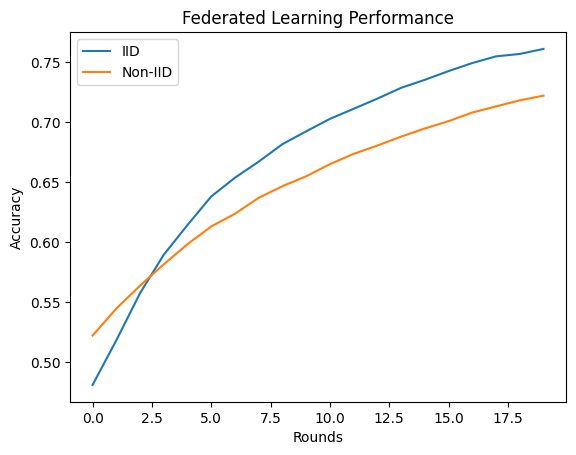

In [11]:
plt.plot(iid_acc, label="IID")
plt.plot(noniid_acc, label="Non-IID")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.title("Federated Learning Performance")
plt.legend()
plt.show()

# **Add Stratification (Improvement)**

To reduce degradation:

Option 1: Weighted FedAvg

In [14]:
def fedavg(global_model, client_states):
   global_dict[key] = torch.sum(
    torch.stack([client_states[i][key] * len(clients[i][0])
    for i in range(len(clients))]), dim=0
) / sum([len(clients[i][0]) for i in range(len(clients))])



**Option 2: Increase Local Epochs**

local_train(model, data, epochs=5)

**Option 3: Use FedProx Regularization**

Add proximal term:

loss += mu/2 * torch.norm(param - global_param)**2